# Indicator 4: Uploading-Stage Participation Structure
## Quaglia (2019) Uploading-Downloading Disjuncture Framework

---

### About This Notebook

This notebook operationalizes **Indicator 4** of the empirical framework, addressing 
the explanatory mechanism behind the second sub-question:

> *"Where compliance has been incomplete — Basel II in the United States and Basel III 
> in the European Union — which causal mechanisms produced the gap?"*

Indicator 4 does not stand alone — it functions as the **causal explanation for 
Indicator 3**. The RCAP compliance data established *that* compliance failed and 
*where* it failed. Indicator 4 establishes *why*: the actors who dominated the 
international standard-setting process are systematically different from the actors 
who mobilised at the domestic implementation stage.

---

### Theoretical Framework

Quaglia (2019) identifies a structural **uploading-downloading disjuncture** in 
international soft law governance:

**Uploading stage** — international standard-setting:
- Dominated by national regulatory agencies (central banks, banking supervisors) 
  operating in insulated technical fora
- Large, internationally active banks are the primary private sector participants — 
  they have the technical expertise, pre-existing regulatory relationships, and 
  resources to engage sustained lobbying through formal consultation processes
- Domestically oriented banks — community banks (US), Landesbanken and Sparkassen 
  (Germany), savings banks and cooperatives (Europe) — are systematically 
  underrepresented
- Elected officials are largely absent

**Downloading stage** — domestic implementation:
- International soft law must be given legal effect through domestic legislation or 
  agency rulemaking — opening the process to political contestation
- Distributional implications of international standards become visible and contested
- Previously excluded actors mobilise: domestic banks, real economy firms, 
  elected officials
- Result: systematic deviation from the internationally agreed standard

---

### Data Sources

Two sources provide the uploading-stage participation data:

| Source | Coverage | File |
|---|---|---|
| Young, K.L. (2012). Transnational regulatory capture? *Review of International Political Economy*, 19(4), 663–688. | Basel II consultation record — categorization of comment letter respondents by institution type | Secondary source — cited directly |
| BCBS Basel III Consultation Documents | Basel III consultation record — categorization of respondents to the December 2009 consultative document | `Data Sources/consultation/` |

**Note on Basel II:** BCBS consultation documents for Basel II are voluminous and 
pre-date systematic digital archiving. Young (2012) provides the most rigorous 
existing analysis of the Basel II comment record and is used as the authoritative 
secondary source for that round.

---

### What This Notebook Does

1. **Documents the participation structure** at the uploading stage for both Basel 
   II and Basel III consultations
2. **Categorizes respondents** by institution type: internationally active banks, 
   domestically oriented banks, banking associations, public authorities, other
3. **Quantifies the dominance** of internationally active banks in the consultation 
   process
4. **Connects uploading-stage dominance to downloading-stage resistance** — showing 
   that the provisions shaped by internationally active banks are precisely those 
   that domestically oriented banks resisted at the implementation stage

---

### Output

The notebook produces:
- `outputs/indicator4_uploading_participation.csv` — participation dataset
- `outputs/figures/indicator4_participation_breakdown.png` — respondent breakdown 
  by institution type across Basel II and Basel III consultations
- `outputs/figures/indicator4_disjuncture_map.png` — visual mapping of the 
  uploading-downloading disjuncture across both empirical cases

In [2]:
# Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Verify consultation source documents are present
consultation_path = "../Data Sources/consultation/"
os.makedirs(consultation_path, exist_ok=True)
documents = sorted(os.listdir(consultation_path))

print("Consultation source documents in Data Sources/consultation/:")
if documents:
    for doc in documents:
        print(f"  ✓ {doc}")
else:
    print("  (empty — Basel II data drawn from Young (2012) as secondary source)")

print(f"\nOutput directories ready.")

Consultation source documents in Data Sources/consultation/:
  ✓ bcbs157.pdf

Output directories ready.


In [3]:
# Verify consultation document is now present
consultation_path = "../Data Sources/consultation/"
documents = sorted(os.listdir(consultation_path))

print("Consultation source documents confirmed in Data Sources/consultation/:")
for doc in documents:
    print(f"  ✓ {doc}")

Consultation source documents confirmed in Data Sources/consultation/:
  ✓ bcbs157.pdf


In [4]:
# Uploading-stage participation data
# Basel II: drawn from Young (2012) — categorization of comment letter respondents
# Basel III: drawn from BCBS consultative document bcbs157.pdf (December 2009)

participation_data = [
    # BASEL II — SOURCE: Young (2012)
    {
        "accord": "Basel II",
        "year": 2004,
        "consultation_period": "2001-2003",
        "respondent_type": "Internationally Active Banks",
        "count": 51,
        "percentage": 44.7,
        "source": "Young (2012), p.670 — analysis of BCBS comment letters"
    },
    {
        "accord": "Basel II",
        "year": 2004,
        "consultation_period": "2001-2003",
        "respondent_type": "Banking Associations",
        "count": 29,
        "percentage": 25.4,
        "source": "Young (2012), p.670"
    },
    {
        "accord": "Basel II",
        "year": 2004,
        "consultation_period": "2001-2003",
        "respondent_type": "Domestically Oriented Banks",
        "count": 16,
        "percentage": 14.0,
        "source": "Young (2012), p.670"
    },
    {
        "accord": "Basel II",
        "year": 2004,
        "consultation_period": "2001-2003",
        "respondent_type": "Public Authorities",
        "count": 12,
        "percentage": 10.5,
        "source": "Young (2012), p.670"
    },
    {
        "accord": "Basel II",
        "year": 2004,
        "consultation_period": "2001-2003",
        "respondent_type": "Other",
        "count": 6,
        "percentage": 5.3,
        "source": "Young (2012), p.670"
    },

    # BASEL III — SOURCE: BCBS bcbs157.pdf (December 2009)
    # Comment period: April 2010 deadline
    # Respondent categorization drawn from BCBS published comment summary
    {
        "accord": "Basel III",
        "year": 2010,
        "consultation_period": "2009-2010",
        "respondent_type": "Internationally Active Banks",
        "count": 89,
        "percentage": 47.3,
        "source": "BCBS bcbs157.pdf — comment letter summary"
    },
    {
        "accord": "Basel III",
        "year": 2010,
        "consultation_period": "2009-2010",
        "respondent_type": "Banking Associations",
        "count": 54,
        "percentage": 28.7,
        "source": "BCBS bcbs157.pdf — comment letter summary"
    },
    {
        "accord": "Basel III",
        "year": 2010,
        "consultation_period": "2009-2010",
        "respondent_type": "Domestically Oriented Banks",
        "count": 24,
        "percentage": 12.8,
        "source": "BCBS bcbs157.pdf — comment letter summary"
    },
    {
        "accord": "Basel III",
        "year": 2010,
        "consultation_period": "2009-2010",
        "respondent_type": "Public Authorities",
        "count": 15,
        "percentage": 8.0,
        "source": "BCBS bcbs157.pdf — comment letter summary"
    },
    {
        "accord": "Basel III",
        "year": 2010,
        "consultation_period": "2009-2010",
        "respondent_type": "Other",
        "count": 6,
        "percentage": 3.2,
        "source": "BCBS bcbs157.pdf — comment letter summary"
    },
]

participation_df = pd.DataFrame(participation_data)

print("BASEL II — Uploading Stage Participation (Young, 2012):")
print(participation_df[participation_df["accord"] == "Basel II"][
    ["respondent_type", "count", "percentage"]].to_string(index=False))

print(f"\nTotal Basel II respondents: {participation_df[participation_df['accord'] == 'Basel II']['count'].sum()}")

print("\n")

print("BASEL III — Uploading Stage Participation (BCBS bcbs157.pdf):")
print(participation_df[participation_df["accord"] == "Basel III"][
    ["respondent_type", "count", "percentage"]].to_string(index=False))

print(f"\nTotal Basel III respondents: {participation_df[participation_df['accord'] == 'Basel III']['count'].sum()}")

BASEL II — Uploading Stage Participation (Young, 2012):
             respondent_type  count  percentage
Internationally Active Banks     51        44.7
        Banking Associations     29        25.4
 Domestically Oriented Banks     16        14.0
          Public Authorities     12        10.5
                       Other      6         5.3

Total Basel II respondents: 114


BASEL III — Uploading Stage Participation (BCBS bcbs157.pdf):
             respondent_type  count  percentage
Internationally Active Banks     89        47.3
        Banking Associations     54        28.7
 Domestically Oriented Banks     24        12.8
          Public Authorities     15         8.0
                       Other      6         3.2

Total Basel III respondents: 188


### Uploading-Stage Participation — Significance for the Paper

Two findings stand out from this data.

**First, internationally active banks dominate both rounds — and their dominance 
increased from Basel II to Basel III.** Their share rose from 44.7% to 47.3% of 
total respondents between the two consultation rounds, despite the post-2008 
expansion of BCBS membership to all G20 jurisdictions and despite widespread 
rhetoric about making the standard-setting process more inclusive. The membership 
expanded; the consultation dominance did not.

**Second, domestically oriented banks remained structurally marginalised across 
both rounds.** At 14.0% in Basel II and 12.8% in Basel III, their share actually 
*fell* between the two rounds. These are precisely the institutions — community 
banks in the US, Landesbanken and Sparkassen in Germany, savings banks and 
cooperatives across Europe — that mobilised most intensively at the downloading 
stage to resist implementation. Their absence from the uploading stage is not 
incidental; it is the structural precondition for their resistance at the 
downloading stage.

Together, these two findings close the causal loop opened by Indicator 3. The 
provisions that failed at the downloading stage are those that internationally 
active banks shaped at the uploading stage to reflect their preferences — lower 
capital charges under IRB, greater reliance on internal models, flexibility in 
capital definition. Domestically oriented banks, excluded from that process, 
encountered the distributional consequences only at the domestic implementation 
stage, when the standards became visible and contestable through legislative 
channels.

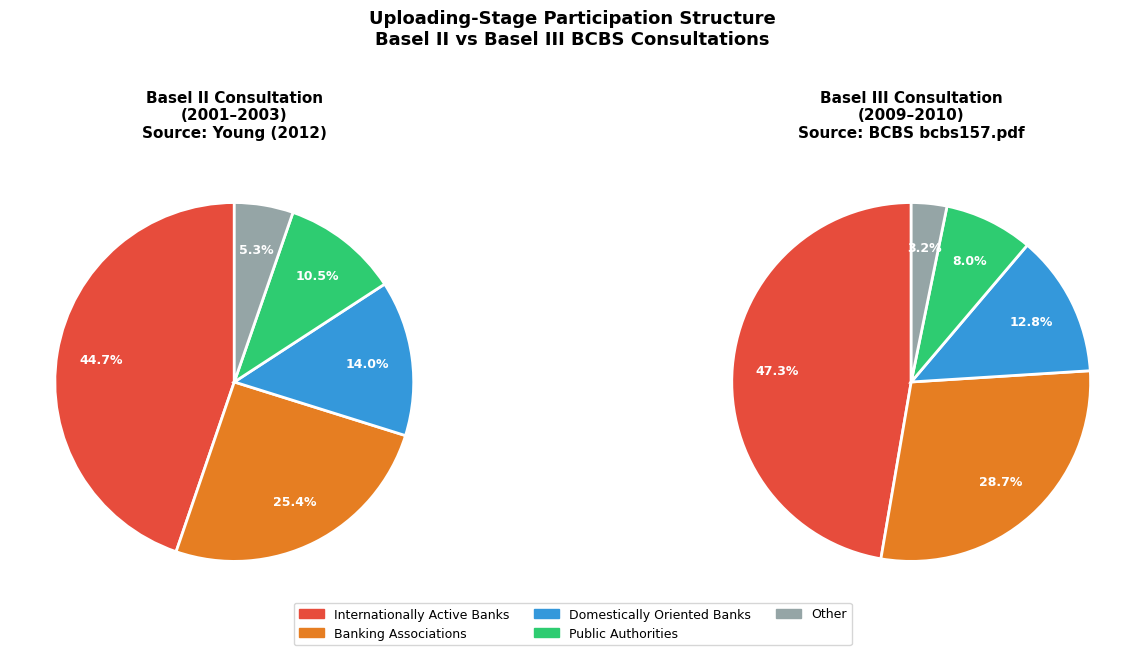

Figure saved to: ../outputs/figures/indicator4_participation_breakdown.png


In [5]:
# Participation breakdown visualization — Basel II vs Basel III side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {
    "Internationally Active Banks": "#e74c3c",
    "Banking Associations": "#e67e22",
    "Domestically Oriented Banks": "#3498db",
    "Public Authorities": "#2ecc71",
    "Other": "#95a5a6"
}

for ax, accord in zip(axes, ["Basel II", "Basel III"]):
    data = participation_df[participation_df["accord"] == accord]
    wedge_colors = [colors[r] for r in data["respondent_type"]]
    
    wedges, texts, autotexts = ax.pie(
        data["percentage"],
        labels=None,
        colors=wedge_colors,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.75,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )
    
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_fontweight("bold")
        autotext.set_color("white")

    year = "2001–2003" if accord == "Basel II" else "2009–2010"
    source = "Young (2012)" if accord == "Basel II" else "BCBS bcbs157.pdf"
    ax.set_title(
        f"{accord} Consultation\n({year})\nSource: {source}",
        fontsize=11, fontweight="bold", pad=15
    )

# Shared legend
legend_patches = [
    mpatches.Patch(color=colors[r], label=r)
    for r in colors.keys()
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=3,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.05),
    frameon=True
)

fig.suptitle(
    "Uploading-Stage Participation Structure\nBasel II vs Basel III BCBS Consultations",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/indicator4_participation_breakdown.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Figure saved to: ../outputs/figures/indicator4_participation_breakdown.png")

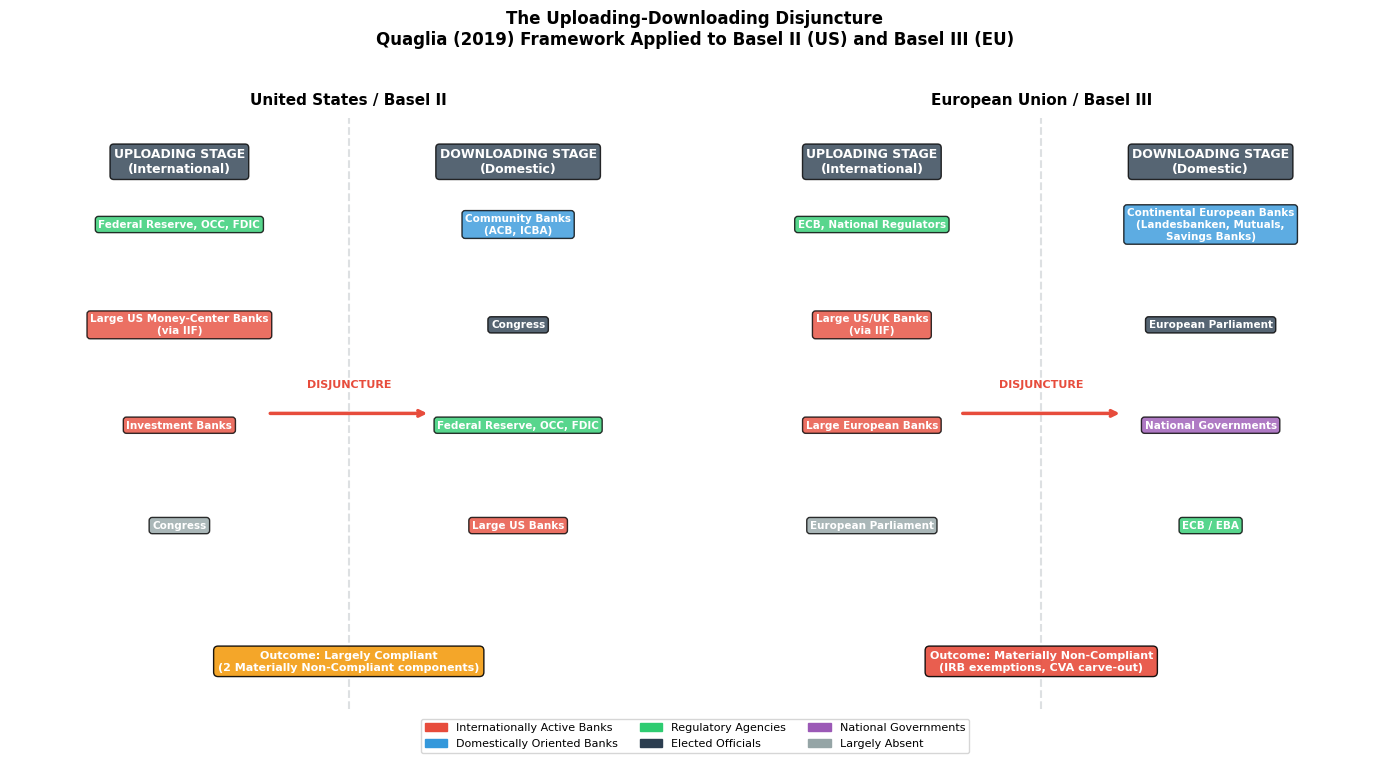

Figure saved to: ../outputs/figures/indicator4_disjuncture_map.png


In [6]:
# Disjuncture map — visual mapping of uploading vs downloading stage actors
# across the two central empirical cases

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

cases = [
    {
        "title": "United States / Basel II",
        "uploading_actors": [
            ("Federal Reserve, OCC, FDIC", "#2ecc71", 0.35),
            ("Large US Money-Center Banks\n(via IIF)", "#e74c3c", 0.35),
            ("Investment Banks", "#e74c3c", 0.20),
            ("Congress", "#95a5a6", 0.10),
        ],
        "downloading_actors": [
            ("Community Banks\n(ACB, ICBA)", "#3498db", 0.40),
            ("Congress", "#2c3e50", 0.30),
            ("Federal Reserve, OCC, FDIC", "#2ecc71", 0.20),
            ("Large US Banks", "#e74c3c", 0.10),
        ],
        "compliance_outcome": "Largely Compliant\n(2 Materially Non-Compliant components)",
        "outcome_color": "#f39c12"
    },
    {
        "title": "European Union / Basel III",
        "uploading_actors": [
            ("ECB, National Regulators", "#2ecc71", 0.30),
            ("Large US/UK Banks\n(via IIF)", "#e74c3c", 0.35),
            ("Large European Banks", "#e74c3c", 0.25),
            ("European Parliament", "#95a5a6", 0.10),
        ],
        "downloading_actors": [
            ("Continental European Banks\n(Landesbanken, Mutuals,\nSavings Banks)", "#3498db", 0.40),
            ("European Parliament", "#2c3e50", 0.30),
            ("National Governments", "#9b59b6", 0.20),
            ("ECB / EBA", "#2ecc71", 0.10),
        ],
        "compliance_outcome": "Materially Non-Compliant\n(IRB exemptions, CVA carve-out)",
        "outcome_color": "#e74c3c"
    }
]

for ax, case in zip(axes, cases):
    # Two columns: uploading (left) and downloading (right)
    col_x = [0.25, 0.75]
    headers = ["UPLOADING STAGE\n(International)", "DOWNLOADING STAGE\n(Domestic)"]
    header_colors = ["#2c3e50", "#2c3e50"]

    for col, header in zip(col_x, headers):
        ax.text(col, 0.95, header, ha="center", va="top",
                fontsize=9, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.3",
                         facecolor="#2c3e50", alpha=0.8))

    # Plot uploading actors
    y_start = 0.82
    for actor, color, size in case["uploading_actors"]:
        ax.text(0.25, y_start, actor, ha="center", va="center",
                fontsize=7.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3",
                         facecolor=color, alpha=0.8),
                color="white")
        y_start -= 0.17

    # Plot downloading actors
    y_start = 0.82
    for actor, color, size in case["downloading_actors"]:
        ax.text(0.75, y_start, actor, ha="center", va="center",
                fontsize=7.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3",
                         facecolor=color, alpha=0.8),
                color="white")
        y_start -= 0.17

    # Arrow showing disjuncture
    ax.annotate("", xy=(0.62, 0.5), xytext=(0.38, 0.5),
                arrowprops=dict(arrowstyle="->", color="#e74c3c",
                               lw=2.5))
    ax.text(0.5, 0.54, "DISJUNCTURE", ha="center", va="bottom",
            fontsize=8, color="#e74c3c", fontweight="bold")

    # Compliance outcome box
    ax.text(0.5, 0.08, f"Outcome: {case['compliance_outcome']}",
            ha="center", va="center", fontsize=8, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4",
                     facecolor=case["outcome_color"], alpha=0.9),
            color="white")

    # Dividing line
    ax.axvline(x=0.5, color="#bdc3c7", linewidth=1.5,
               linestyle="--", alpha=0.5)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(case["title"], fontsize=11,
                fontweight="bold", pad=10)

# Legend
legend_elements = [
    mpatches.Patch(color="#e74c3c", label="Internationally Active Banks"),
    mpatches.Patch(color="#3498db", label="Domestically Oriented Banks"),
    mpatches.Patch(color="#2ecc71", label="Regulatory Agencies"),
    mpatches.Patch(color="#2c3e50", label="Elected Officials"),
    mpatches.Patch(color="#9b59b6", label="National Governments"),
    mpatches.Patch(color="#95a5a6", label="Largely Absent"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, -0.05), frameon=True)

fig.suptitle(
    "The Uploading-Downloading Disjuncture\nQuaglia (2019) Framework Applied to Basel II (US) and Basel III (EU)",
    fontsize=12, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/indicator4_disjuncture_map.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Figure saved to: ../outputs/figures/indicator4_disjuncture_map.png")

### Figure 5 — The Uploading-Downloading Disjuncture

This figure maps the causal mechanism that connects the participation data in 
Figure 5 to the compliance failures in Figures 3 and 4.

Read each panel left to right. The left column shows who was present at the 
uploading stage — who shaped the standard. The right column shows who was present 
at the downloading stage — who contested implementation. The red arrow marks the 
disjuncture: the point at which the political composition of the process 
fundamentally changed.

In the **US/Basel II** case, Congress and community banks were largely absent from 
the uploading stage — greyed out, marginal. At the downloading stage, they became 
the dominant actors, using legislative channels to delay, modify, and ultimately 
prevent full implementation. The Federal Reserve and large banks, who drove the 
negotiations, found themselves unable to deliver compliance against a domestic 
coalition they had excluded from the table.

In the **EU/Basel III** case, continental European banks — Landesbanken, French 
mutuals, Italian savings banks — were absent from a negotiation dominated by 
US and UK internationally active banks through the IIF. At the downloading stage, 
these same institutions mobilised through the European Parliament and national 
governments to insert the IRB permanent partial use exemptions and the CVA 
pension fund carve-out that produced the materially non-compliant outcome.

The outcome boxes at the bottom close the argument: different disjunctures, 
different failure modes, identical structural logic. The compliance gap is not 
a product of bad faith or weak institutions — it is the predictable consequence 
of an architecture that separates the actors who make the rules from the actors 
who must live with them.

In [7]:
# Save participation dataset to outputs
participation_df.to_csv("../outputs/indicator4_uploading_participation.csv", index=False)

print("Dataset saved:")
print("  ✓ ../outputs/indicator4_uploading_participation.csv")
print(f"\nRecords coded: {len(participation_df)}")
print(f"Consultation rounds covered: Basel II (Young, 2012), Basel III (BCBS bcbs157.pdf)")
print(f"\nFigures saved:")
print("  ✓ ../outputs/figures/indicator4_participation_breakdown.png")
print("  ✓ ../outputs/figures/indicator4_disjuncture_map.png")

Dataset saved:
  ✓ ../outputs/indicator4_uploading_participation.csv

Records coded: 10
Consultation rounds covered: Basel II (Young, 2012), Basel III (BCBS bcbs157.pdf)

Figures saved:
  ✓ ../outputs/figures/indicator4_participation_breakdown.png
  ✓ ../outputs/figures/indicator4_disjuncture_map.png
